The Movies Dataset i MovieLens łączymy za pomocą links.csv

In [1]:
import pandas as pd
from pathlib import Path

archive_path = Path("data/archive")
small_path = Path("data/ml-latest-small")

def safe_int64(col):
    return pd.to_numeric(col, errors='coerce').astype('Int64')

def load_cleaned_files(path):
    files = list(path.glob("*_cleaned.csv"))
    dfs = {}
    for f in files:
        name = f.stem.replace("_cleaned", "")
        dfs[name] = pd.read_csv(f, low_memory=False)
    return dfs

archive_dfs = load_cleaned_files(archive_path)
small_dfs = load_cleaned_files(small_path)

if 'links' in archive_dfs and 'movies_metadata' in archive_dfs:
    archive_dfs['links']['tmdbId'] = safe_int64(archive_dfs['links']['tmdbId'])
    archive_dfs['movies_metadata']['id'] = safe_int64(archive_dfs['movies_metadata']['id'])
    archive_dfs['movies_full'] = archive_dfs['movies_metadata'].merge(
        archive_dfs['links'][['tmdbId', 'imdbId']],
        left_on='id', right_on='tmdbId', how='left'
    )

if 'links' in small_dfs and 'movies' in small_dfs:
    small_dfs['links']['tmdbId'] = safe_int64(small_dfs['links']['tmdbId'])
    small_dfs['movies']['movieId'] = safe_int64(small_dfs['movies']['movieId'])
    small_dfs['movies_full'] = small_dfs['movies'].merge(
        small_dfs['links'][['tmdbId', 'imdbId']],
        left_on='movieId', right_on='tmdbId', how='left'
    )

print(archive_dfs['movies_full'].head())
print(small_dfs['movies_full'].head())

   adult           belongs_to_collection    budget                    genres  \
0  False            toy_story_collection  30000000   animation comedy family   
1  False                             NaN  65000000  adventure fantasy family   
2  False       grumpy_old_men_collection         0            romance comedy   
3  False                             NaN  16000000      comedy drama romance   
4  False  father_of_the_bride_collection         0                    comedy   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709                en   
1                               unknown   8844  tt0113497                en   
2                               unknown  15602  tt0113228                en   
3                               unknown  31357  tt0114885                en   
4                               unknown  11862  tt0113041                en   

                original_title  \
0         

In [11]:
print(small_dfs.keys())
print(archive_dfs.keys())

dict_keys(['links', 'movies', 'ratings', 'tags', 'movies_full'])
dict_keys(['credits', 'keywords', 'links', 'links_small', 'movies_metadata', 'ratings', 'ratings_small', 'movies_full'])


In [42]:
print(small_dfs['movies_full'].head())

   movieId                        title  \
0        1                    Toy Story   
1        2                      Jumanji   
2        3             Grumpier Old Men   
3        4            Waiting to Exhale   
4        5  Father of the Bride Part II   

                                        genres    year  tmdbId    imdbId  
0  Adventure|Animation|Children|Comedy|Fantasy  1995.0    <NA>       NaN  
1                   Adventure|Children|Fantasy  1995.0       2   94675.0  
2                               Comedy|Romance  1995.0    <NA>       NaN  
3                         Comedy|Drama|Romance  1995.0    <NA>       NaN  
4                                       Comedy  1995.0       5  113101.0  


In [43]:
import matplotlib.pyplot as plt

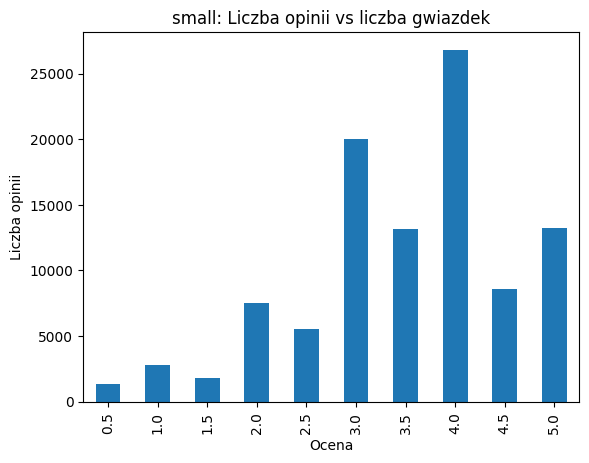

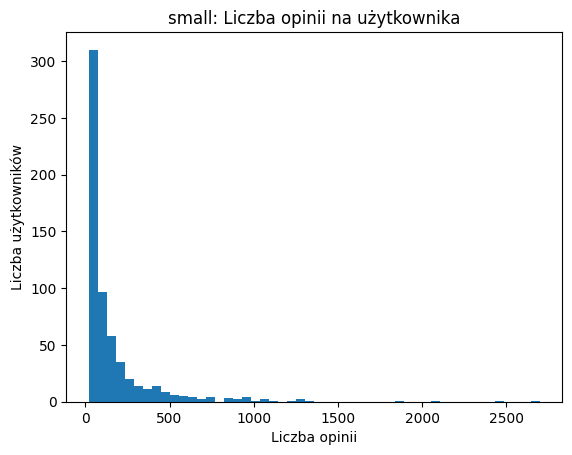

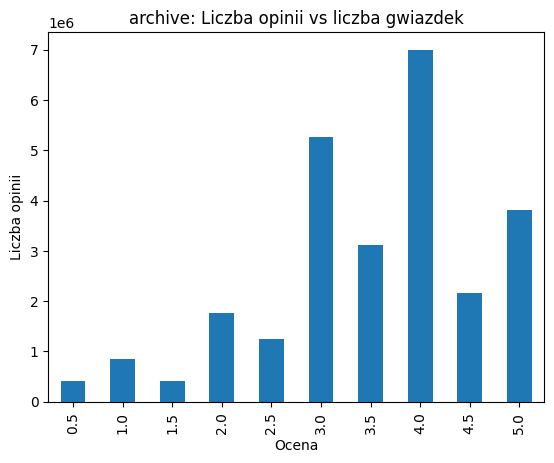

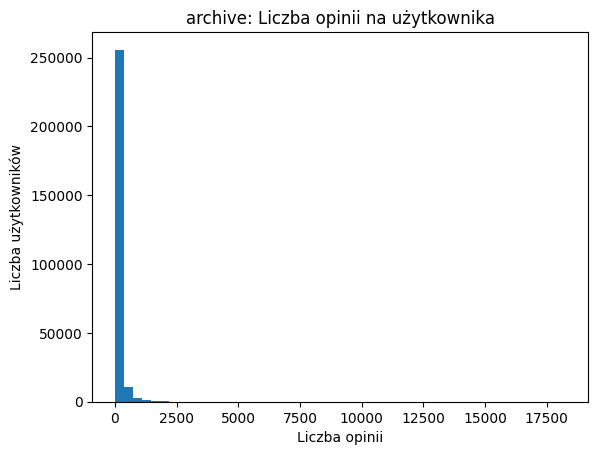

In [57]:
datasets = {
    "small": small_dfs,
    "archive": archive_dfs
}

for name, dfs in datasets.items():
    ratings = dfs['ratings']

    star_counts = ratings['rating'].value_counts().sort_index()

    plt.figure()
    star_counts.plot(kind='bar')
    plt.title(f"{name}: Liczba opinii vs liczba gwiazdek")
    plt.xlabel("Ocena")
    plt.ylabel("Liczba opinii")
    plt.show()

    user_counts = ratings['userId'].value_counts()

    plt.figure()
    user_counts.plot(kind='hist', bins=50)
    plt.title(f"{name}: Liczba opinii na użytkownika")
    plt.xlabel("Liczba opinii")
    plt.ylabel("Liczba użytkowników")
    plt.show()

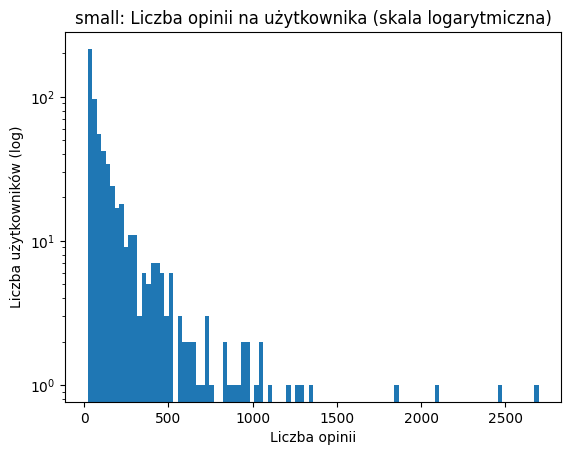

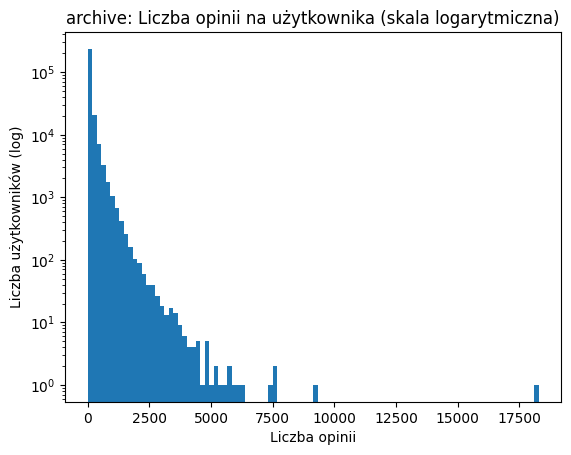

In [51]:
plt.figure()
plt.hist(small_dfs['ratings']['userId'].value_counts(), bins=100)
plt.yscale('log')   # 🔥 kluczowa linia
plt.title("small: Liczba opinii na użytkownika (skala logarytmiczna)")
plt.xlabel("Liczba opinii")
plt.ylabel("Liczba użytkowników (log)")
plt.show()

plt.figure()
plt.hist(archive_dfs['ratings']['userId'].value_counts(), bins=100)
plt.yscale('log')   # 🔥 kluczowa linia
plt.title("archive: Liczba opinii na użytkownika (skala logarytmiczna)")
plt.xlabel("Liczba opinii")
plt.ylabel("Liczba użytkowników (log)")
plt.show()

In [56]:
archive_titles = set(archive_dfs['movies_full']['original_title'].dropna())
small_titles = set(small_dfs['movies_full']['title'].dropna())

common_movies = archive_titles & small_titles

print("Liczba filmów w datasecie small",len(small_titles))
print("Liczba filmów w datasecie archive",len(archive_titles))
print("Liczba wspólnych filmów:", len(common_movies))
print()
print("Pokrycie small w archive:", len(common_movies) / len(small_titles) * 100, "%")

print("Pokrycie archive w small:", len(common_movies) / len(archive_titles) * 100, "%")

Liczba filmów w datasecie small 9461
Liczba filmów w datasecie archive 43371
Liczba wspólnych filmów: 6139

Pokrycie small w archive: 64.88743261811648 %
Pokrycie archive w small: 14.154619446173712 %
